In [3]:
import os 
import glob

os.chdir('E:/GitHubProjects/autolabeling_time_series_data/')

import pandas as pd
import numpy as np
import datetime

import core.utils.visuals_tools as vis 

In [4]:
files = glob.glob('nir_folder/financial_series/raw_prices/*.csv')
files

['nir_folder/financial_series/raw_prices\\ADA_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\ALGO_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\AVAX_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\AXS_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\BNB_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\BTC_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\DOGE_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\DOT_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\ETH_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\LINK_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\LTC_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\NEAR_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\SOL_USD__1d__01_01_2021.csv',
 'nir_folder/financial_series/raw_prices\\TRX_USD__1d__01_0

In [5]:
data = pd.read_csv(files[0])
data['date'] = pd.to_datetime(data['timestamp']).apply(lambda x: x.date())
data

,timestamp,open,close,high,low,volume,support,resis,date
0,2021-01-01 03:00:00,0.18134,0.18473,0.17000,0.17509,4.622016e+08,NaN,NaN,2021-01-01
1,2021-01-02 03:00:00,0.17505,0.18457,0.16793,0.17742,6.603033e+08,0.18473,0.18473,2021-01-02
2,2021-01-03 03:00:00,0.17740,0.20960,0.17255,0.20615,1.201451e+09,0.18457,0.18473,2021-01-03
3,2021-01-04 03:00:00,0.20625,0.23992,0.19203,0.22528,1.463416e+09,0.18457,0.20960,2021-01-04
4,2021-01-05 03:00:00,0.22518,0.26429,0.20696,0.25873,1.478888e+09,0.18457,0.23992,2021-01-05
...,...,...,...,...,...,...,...,...,...
1466,2025-01-06 03:00:00,1.09110,1.11620,1.05750,1.09340,1.813959e+08,0.87910,1.11940,2025-01-06
1467,2025-01-07 03:00:00,1.09340,1.15190,0.98800,0.98920,3.655628e+08,0.87910,1.11940,2025-01-07
1468,2025-01-08 03:00:00,0.98930,1.02420,0.90790,0.94680,3.698014e+08,0.87910,1.15190,2025-01-08
1469,2025-01-09 03:00:00,0.94670,0.96040,0.87980,0.90450,2.393583e+08,0.87910,1.15190,2025-01-09


# Анализ 2 последних лет

Анализ сухих цен приведет к простому делению на кластеры. Один кластер это BTC и в некоторых ETH и остальные. 

Анализ return более удобен, потому что анализируем одинаковые величины

https://www.codearmo.com/blog/sharpe-sortino-and-calmar-ratios-python

по итогу анализа было получено, что в текущем состоянии рынка маленькие крипты более интересны, нежели большие гиганты. Однако, гиганты более стабильны. Наиболее перспективные варианты это XRP, ADA, SOL. BTC и BNB тоже интересны. ETH показывает слабые результаты, но все те же 45% тотал ретерна за 2024-2025

In [72]:
raw_price_dict = {}

start_date = datetime.date(2024,6,1)

for file in files:
    name = file.split('\\')[-1].split('_')[0]
    data = pd.read_csv(file)
    data['date'] = pd.to_datetime(data['timestamp']).apply(lambda x: x.date())
    
    raw_price_dict[name] = data.loc[data.date >= start_date, 'close'].round(5).values

raw_price_dict['date'] = data.loc[data.date >= start_date, 'date'].values

In [73]:
close_prices_df = pd.DataFrame(raw_price_dict)

# close_prices_df = close_prices_df.drop(['BTC', 'ETH', 'BNB'], axis=1)
close_prices_df_no_date = close_prices_df.drop('date', axis=1)
return_df_no_date = close_prices_df_no_date.pct_change().dropna()

close_prices_df.head()

,ADA,ALGO,AVAX,AXS,BNB,BTC,DOGE,DOT,ETH,LINK,LTC,NEAR,SOL,TRX,UNI,VET,XRP,date
0,0.4533,0.1896,36.22,8.287,608.4,67900.00,0.16199,7.135,3833.30,18.686,83.74,7.468,167.95,0.11296,10.072,0.03399,0.5219,2024-06-01
1,0.4541,0.1897,36.18,8.350,606.0,68460.00,0.16137,7.125,3838.59,18.566,83.53,7.503,167.10,0.11526,9.959,0.03403,0.5209,2024-06-02
2,0.4632,0.1892,36.27,8.600,638.8,70288.00,0.16346,7.191,3849.99,18.359,84.29,7.385,167.21,0.11519,9.838,0.03458,0.5232,2024-06-03
3,0.4656,0.1870,36.29,8.395,688.2,71063.45,0.16194,7.236,3831.65,17.852,83.70,7.472,171.87,0.11458,11.968,0.03451,0.5303,2024-06-04
4,0.4654,0.1900,36.91,8.708,716.0,71758.00,0.16486,7.298,3887.47,18.082,85.47,7.709,175.60,0.11480,11.596,0.03578,0.5326,2024-06-05


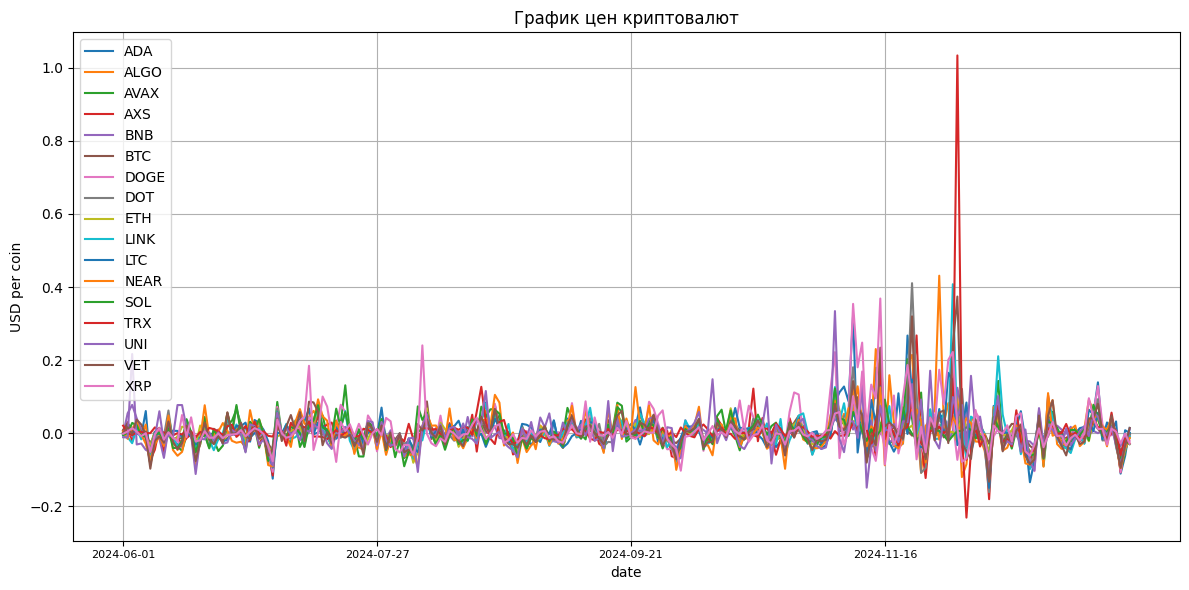

In [74]:
vis.multi_plot_one(return_df_no_date.T.values, list(return_df_no_date.columns), x_series=close_prices_df.date, plot_title='График цен криптовалют', xlabel='date', ylabel='USD per coin')

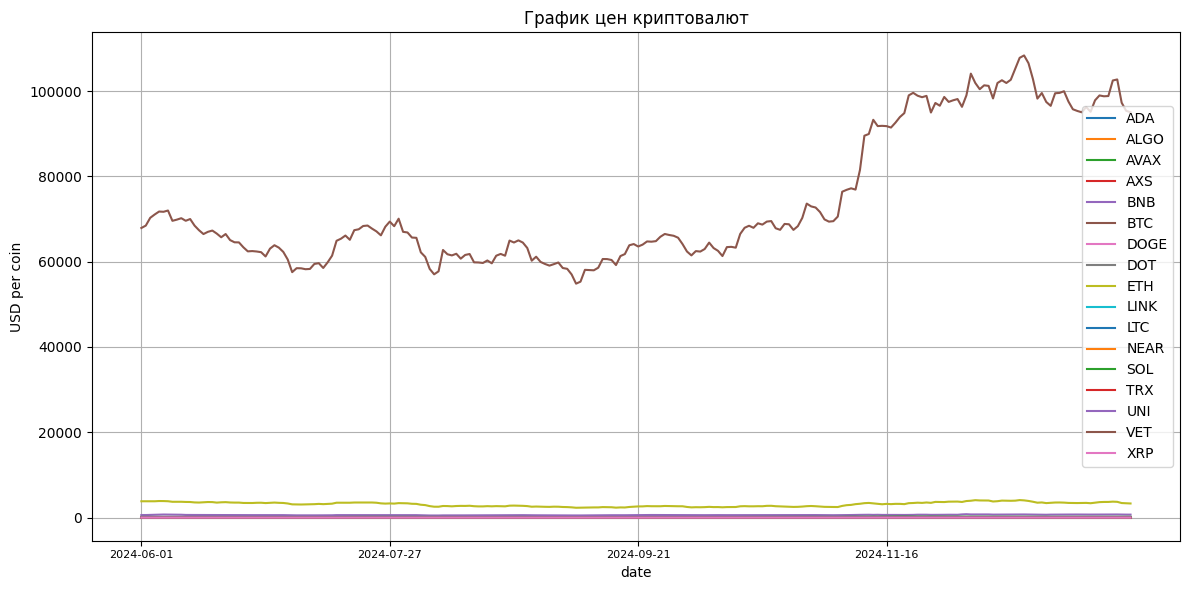

In [75]:
vis.multi_plot_one(close_prices_df_no_date.T.values, list(close_prices_df_no_date.columns), x_series=close_prices_df.date, plot_title='График цен криптовалют', xlabel='date', ylabel='USD per coin')

In [76]:
overall_return = return_df_no_date.sum()
overall_volat = return_df_no_date.std()
overall_mean_return = return_df_no_date.mean()

basics_df = pd.DataFrame([overall_return, overall_mean_return, overall_volat]).T.round(5)
basics_df.columns = ['total_return (sum)', 'mean_return (mean)', 'total_return_volat (std)']
basics_df['sharpe_ratio_daily'] = np.round((252)**(1/2) * basics_df['mean_return (mean)']/basics_df['total_return_volat (std)'],5)

basics_df.sort_values('mean_return (mean)', ascending=False)

,total_return (sum),mean_return (mean),total_return_volat (std),sharpe_ratio_daily
XRP,1.79578,0.00805,0.05407,2.36341
TRX,1.19891,0.00538,0.07539,1.13284
DOGE,1.04078,0.00467,0.05378,1.37847
ADA,1.02430,0.00459,0.04978,1.46372
ALGO,0.95507,0.00428,0.05550,1.22420
VET,0.62259,0.00279,0.05466,0.81028
UNI,0.58641,0.00263,0.05258,0.79403
BTC,0.39315,0.00176,0.02276,1.22755
LTC,0.38030,0.00171,0.03633,0.74719
LINK,0.33859,0.00152,0.04871,0.49537


In [77]:
def sharpe_ratio(return_series, N, rf):
    mean = return_series.mean() * N -rf
    sigma = return_series.std() * np.sqrt(N)
    return mean / sigma

def sortino_ratio(series, N,rf):
    mean = series.mean() * N -rf
    std_neg = series[series<0].std()*np.sqrt(N)
    return mean/std_neg

def max_drawdown(return_series):
    # процент 1.1 * 1.2 * ...
    comp_ret = (return_series+1).cumprod()
    # исторический максимум
    peak = comp_ret.expanding(min_periods=1).max()
    # получаем отношение по цене
    dd = (comp_ret/peak)-1
    return dd.min()

def calmar_ratio(series, max_drawdowns_vals):
    # коэффициент Шарпа только делитель это max_drawdown 
    return series.mean()*255/abs(max_drawdowns_vals) 


N = 252
rf = 0.01

basics_df['sharpe'] = sharpe_ratio(return_df_no_date, N, rf)
basics_df['sortino'] = sortino_ratio(return_df_no_date, N, rf)
basics_df['max_drawdown'] = max_drawdown(return_df_no_date)
basics_df['calmar_ratio'] = calmar_ratio(return_df_no_date, basics_df['max_drawdown'])

# basics_df.to_excel(f'examples/crypto/overall_return_{close_prices_df.date.min()}_{close_prices_df.date.max()}.xlsx')

basics_df

,total_return (sum),mean_return (mean),total_return_volat (std),sharpe_ratio_daily,sharpe,sortino,max_drawdown,calmar_ratio
ADA,1.02430,0.00459,0.04978,1.46372,1.452235,2.897073,-0.337229,3.473264
ALGO,0.95507,0.00428,0.05550,1.22420,1.213681,2.523050,-0.430037,2.539603
AVAX,0.26644,0.00119,0.04490,0.42073,0.408411,0.700601,-0.443280,0.687328
AXS,-0.05380,-0.00024,0.04469,-0.08525,-0.099804,-0.154688,-0.501723,-0.122618
BNB,0.20461,0.00092,0.02454,0.59513,0.567933,0.895821,-0.315046,0.742675
BTC,0.39315,0.00176,0.02276,1.22755,1.202181,2.178869,-0.238163,1.887626
DOGE,1.04078,0.00467,0.05378,1.37847,1.366009,3.018826,-0.422764,2.815117
DOT,0.19025,0.00085,0.04798,0.28123,0.269156,0.520682,-0.473965,0.459001
ETH,-0.06562,-0.00029,0.02689,-0.17120,-0.197112,-0.311272,-0.405457,-0.185070
LINK,0.33859,0.00152,0.04871,0.49537,0.481886,0.986607,-0.452763,0.855136


In [78]:
inx = 0
asc = False
col = basics_df.columns[inx]
print(col)
basics_df.sort_values(col, ascending=asc)

total_return (sum)


,total_return (sum),mean_return (mean),total_return_volat (std),sharpe_ratio_daily,sharpe,sortino,max_drawdown,calmar_ratio
XRP,1.79578,0.00805,0.05407,2.36341,2.352681,5.983224,-0.261275,7.859447
TRX,1.19891,0.00538,0.07539,1.13284,1.123716,3.111097,-0.457111,2.999165
DOGE,1.04078,0.00467,0.05378,1.37847,1.366009,3.018826,-0.422764,2.815117
ADA,1.02430,0.00459,0.04978,1.46372,1.452235,2.897073,-0.337229,3.473264
ALGO,0.95507,0.00428,0.05550,1.22420,1.213681,2.523050,-0.430037,2.539603
VET,0.62259,0.00279,0.05466,0.81028,0.799344,1.835286,-0.452485,1.573387
UNI,0.58641,0.00263,0.05258,0.79403,0.781986,1.526831,-0.509563,1.315953
BTC,0.39315,0.00176,0.02276,1.22755,1.202181,2.178869,-0.238163,1.887626
LTC,0.38030,0.00171,0.03633,0.74719,0.727903,1.064410,-0.308947,1.407604
LINK,0.33859,0.00152,0.04871,0.49537,0.481886,0.986607,-0.452763,0.855136


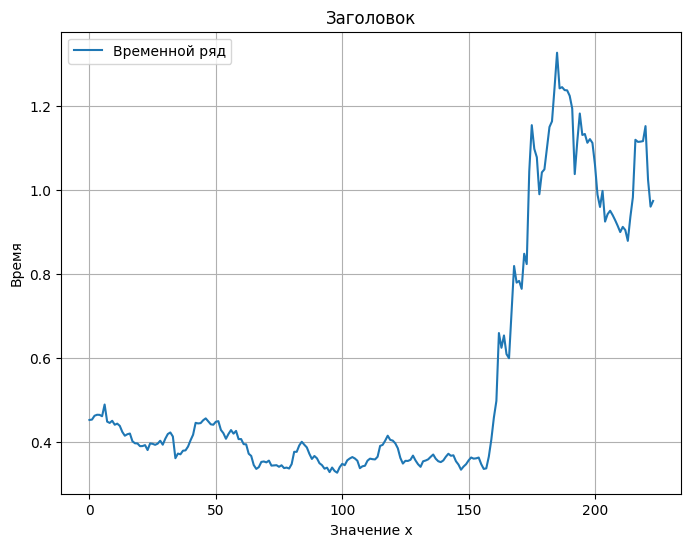

In [55]:
vis.single_plot(close_prices_df_no_date['ADA'])

## Анализ с использованием кластеризации

In [146]:
from core.clustering.density_clustering import *
from core.clustering.partitioning_clustering import *
from core.clustering.hierarchical_clustering import *
from core.feature_extraction.feature_extraction import *

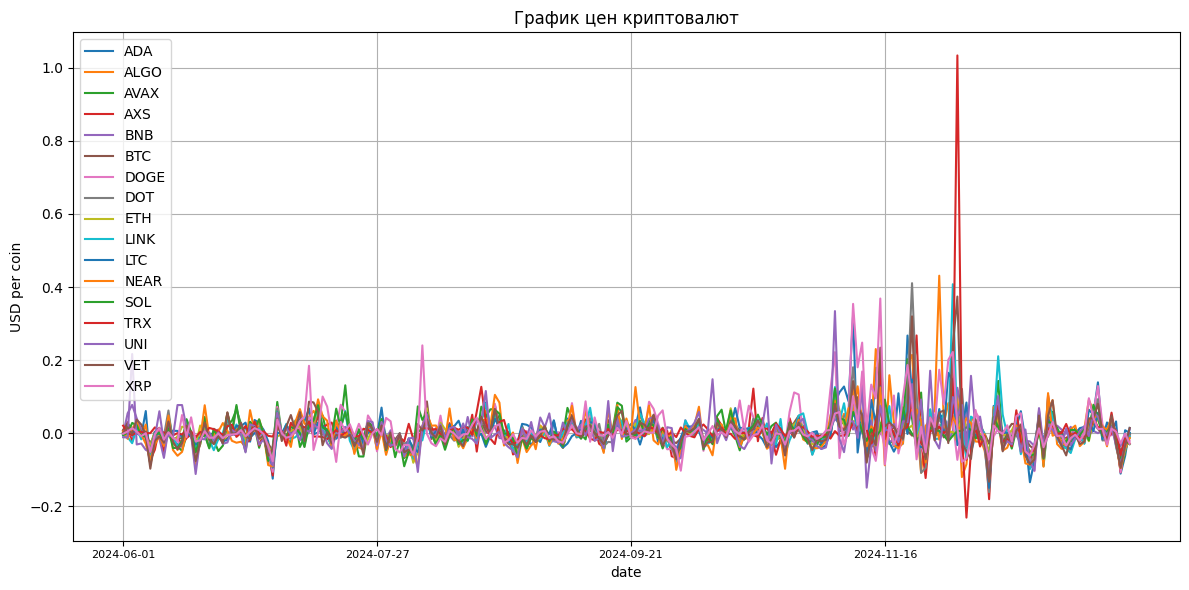

In [80]:
vis.multi_plot_one(return_df_no_date.T.values, list(return_df_no_date.columns), x_series=close_prices_df.date, plot_title='График цен криптовалют', xlabel='date', ylabel='USD per coin')

In [160]:
def create_segments(series, window_size):
    segments = [np.round(np.array(series[i:i + window_size]),5) for i in range(0, len(series), window_size) if len(series[i:i + window_size]) == window_size]
    return segments

def segments_from_table(df, window_size):
    return [create_segments(row, window_size) for i, row in df.iterrows()]

def get_segment(segments, inx, feature_func=None):
    # if feature_func is None:
    #     feature_func = lambda x: x 
    series_dim = len(segments[0])
    return [segments[i][inx] for i in range(series_dim)]

segm_all = segments_from_table(return_df_no_date.T, 14)

assert np.equal(segm_all[-1][-1], return_df_no_date.loc[197:210, 'XRP'].round(5).values).all()

E:\GitHubProjects\autolabeling_time_series_data\core\utils\visuals_tools.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


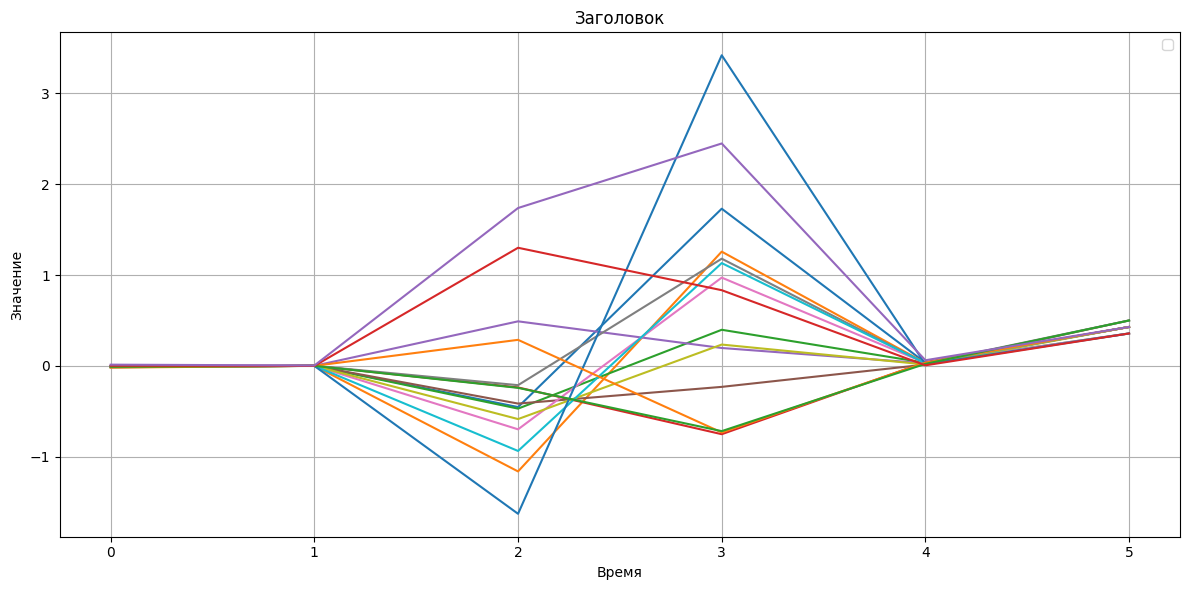

In [162]:
vis.multi_plot_one([statistical_features(row) for i, row in enumerate(get_segment(segm_all, 0))])

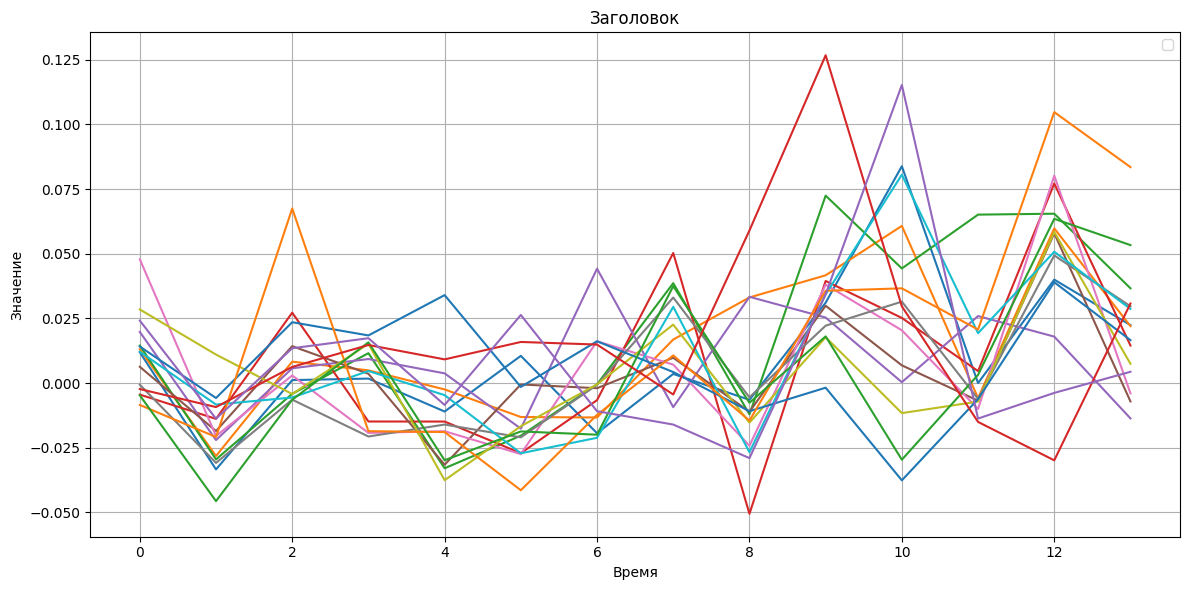

In [174]:
vis.multi_plot_one(get_segment(segm_all, 5))

In [167]:
apply_dbscan(get_segment(segm_all, 4))

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64), DBSCAN())